In [1]:
import requests
import csv
import pandas as pd
import math
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import time
import random
from datetime import datetime, date
import statistics
import requests
from scipy.stats import skew, kurtosis
from scipy import stats
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from scipy.stats import johnsonsu
from scipy.optimize import minimize
from scipy.stats import norm

In [2]:
def get_data(ticker, size='full', date_filter=None):
    """ Retrieve time series data for the price of a security in data frame format
        Sorts so that first date is first index, filters on date if given, renames columns and converts datatypes

    Args:
        ticker (string): The ticker for the security to pull data from
        size (string): 'full' since 1999, 'compact' is last 100 trading days
        date_filter (date string): Filters  data to  keep data only the filter date onward

    Returns:
        df: A dataframe with open, close, high, low, adj close price, volume, split coef, date
    """
    key='&apikey=ZKMMTO1ATDBLXH2K' # API Key
    api_ticker=f'&symbol={ticker}' # Ticker
    endpoint='function=TIME_SERIES_DAILY_ADJUSTED' # Called 'function', the dataset we want
    size=f'&outputsize={size}'
    web='https://www.alphavantage.co/query?'
    url =web+endpoint+api_ticker+size+key

    r = requests.get(url)
    # print(r.status_code) # 200 good, 400 bad
    data = r.json()

    # print(data.keys()) #printing the keys
    meta = data['Meta Data']
    time_series_data = data['Time Series (Daily)']

    ts_df = pd.DataFrame.from_dict(time_series_data, orient='index').reset_index().rename(columns={'index': 'Date'})
    clean_cols_dict = {'1. open': 'Open', '2. high': 'High', '3. low': 'Low', '4. close': 'Close', # Dictionary to convert the names of the columns
                '5. adjusted close': 'Adj Close', '6. volume': 'Volume', '7. dividend amount': 'Dividend', '8. split coefficient': 'Split Coef'}
    ts_df = ts_df.rename(columns=clean_cols_dict)

    ts_df['Date'] = pd.to_datetime(ts_df['Date'])
    if date_filter is not None:
        date_filter = pd.to_datetime(date_filter)
        ts_df = ts_df[ts_df['Date'] >= date_filter]


    ts_df = ts_df.sort_values(by='Date', ascending=True).reset_index().drop(columns='index')
    ts_df['Adj Close'] = ts_df['Adj Close'].astype('float').round(4)
    ts_df['Ticker'] = ticker
    
    return ts_df

In [3]:
def calculate_returns(df, frequency=1):
    """ Calculate the log returns of a security given a df with its prices over a time period

    Args:
        df (dataframe): A dataframe with columns Date, Ticker, Volume, and Adj Close
        frequency (int, optional): How often you want to calculate a return Defaults to 1.

    Returns:
        df: The dataframe from the start with an additional 'Log Return' column which is the log return over the interval for each row
    """
    returns_df = df[['Date', 'Ticker', 'Volume', 'Adj Close']].copy()
    returns_df['Adj Close'] = returns_df['Adj Close'].astype('float')
    returns_df['Log Return'] = np.log(
        returns_df['Adj Close'] / returns_df['Adj Close'].shift(frequency)
    )
    returns_df = returns_df.dropna()

    # If frequency > 1, keep only every `frequency`-th row
    if frequency > 1:
        returns_df = returns_df.iloc[frequency-1::frequency].reset_index(drop=True)

    return returns_df



In [4]:
spy_df = get_data('SPY', size='full', date_filter='2024-01-01')
spy_df = spy_df[spy_df['Date'] <= pd.to_datetime('2026-01-30')]
spy_returns_df = calculate_returns(spy_df, frequency=1)
spy_returns_df

,Date,Ticker,Volume,Adj Close,Log Return
1,2024-01-03,SPY,103585866,456.2369,-0.008200
2,2024-01-04,SPY,84232169,454.7673,-0.003226
3,2024-01-05,SPY,85553758,455.3902,0.001369
4,2024-01-08,SPY,74879074,461.8913,0.014175
5,2024-01-09,SPY,65931439,461.1906,-0.001518
...,...,...,...,...,...
517,2026-01-26,SPY,60473813,690.8159,0.005065
518,2026-01-27,SPY,54124395,693.5683,0.003976
519,2026-01-28,SPY,61172165,693.4985,-0.000101
520,2026-01-29,SPY,97486198,692.1223,-0.001986


In [5]:
def price_european_option(rf, S, K, T, sigma, type='C'):
    """Build Black-Scholes ingredients (d1, d2) for a European option.

    Args:
        rf: Continuously compounded risk-free rate (annual)
        S: Spot price today
        K: Strike
        T: Time to expiry in years
        sigma: Annualized volatility
        type: 'C' for call (put pricing added later)

    Returns:
        dict with d1, d2, and helper terms (price assembly comes next)
    """
    

    # --- Ruler: typical log-price randomness by expiry ---
    sigma_sqrt_T = sigma * np.sqrt(T) # This is a unit of volatility

    # --- Center of LN(S_T) under risk-neutral measure (Ito / GBM) ---
    ln_S_T_mean = np.log(S) + (rf - 0.5 * sigma**2) * T # E^Q[ln S_T] = ln(S) + (r - 1/2 sigma^2) * T

    # --- d2: how many sigma*sqrt(T) units that center is above ln(K) --- 
    d2 = (ln_S_T_mean - np.log(K)) / sigma_sqrt_T # Phi(d2) ~ risk-neutral probability S_T > K (call)

    # --- d1: same scale, shifted up by one sigma*sqrt(T) ---
    d1 = d2 + sigma_sqrt_T # Phi(d1) = call delta (hedge ratio)

    call_price = S * norm.cdf(d1) - K * np.exp(-rf * T) * norm.cdf(d2)
    # The first half is our "delta"/stock exposure. We multiply S by phi(X) (P(d1>0))
    put_price = K * np.exp(-rf * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    if type == 'C':
        return call_price
    elif type == 'P':
        return put_price

    

    

In [6]:
sigma = spy_returns_df['Log Return'].std() * np.sqrt(252)
rf = np.log(1.03)
S = spy_df['Adj Close'].iloc[-1]
K = S * 1.05
T = 0.25

bs_call_price = price_european_option(rf, S, K, T, sigma)
print(bs_call_price)

10.95676806882048


[[ 40.64454019   0.           0.           0.        ]
 [ 65.82830293  17.1149685    0.           0.        ]
 [ 95.7316792   34.5029       0.81672489   0.        ]
 [124.27758218  65.82830293   1.68784729   0.        ]]


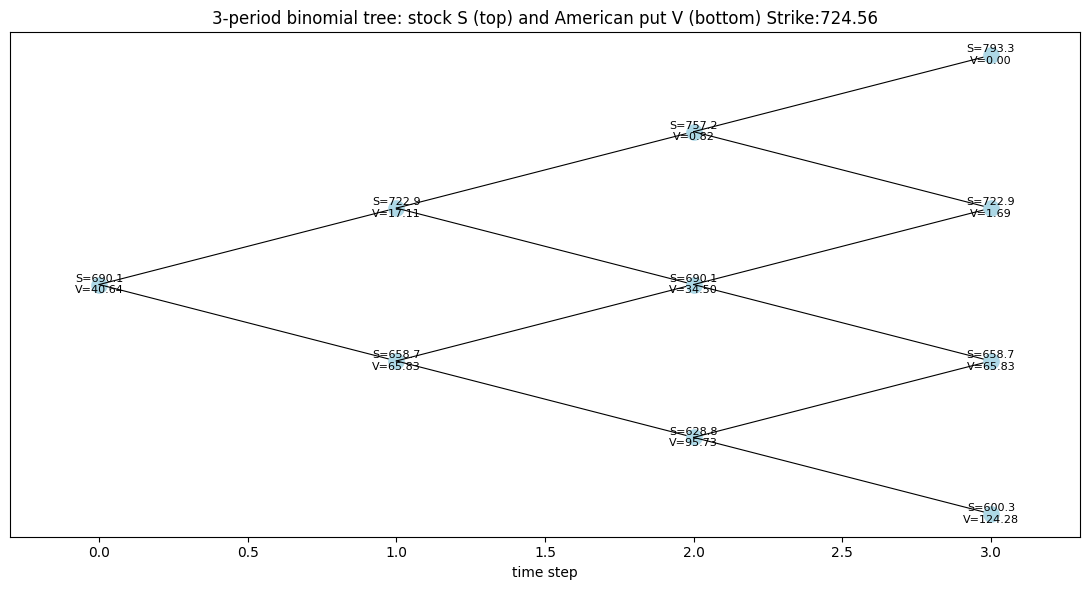

American put (binomial, N=3): 40.6445
European put (Black-Scholes):     40.1251

What happened:
1. Forward: stock moves up (u) or down (d) each period; u,d come from sigma.
2. At expiry (right): put value = max(K - stock, 0).
3. Backward (left): at each node, value = max(exercise now, discounted expected value if you wait).
4. Root value V[0,0] is today's American put. American >= European when early exercise helps.


In [7]:
# --- 3-period binomial American put (uses sigma, S, K, T, rf from above) ---
N = 3
dt = T / N
u = np.exp(sigma * np.sqrt(dt)) # e^(sigma * sqrt(T/N))
d = 1 / u
p = (np.exp(rf * dt) - d) / (u - d)  # risk-neutral up prob per step
disc = np.exp(-rf * dt) # Discounting value of future cash flows

# Stock and option value at each node [time i, j up-moves]
S_tree = np.zeros((N + 1, N + 1)) # Stock price at each node
V_tree = np.zeros((N + 1, N + 1)) # Option price at each node

for i in range(N + 1):
    for j in range(i + 1):
        S_tree[i, j] = S * (u ** j) * (d ** (i - j))

# Expiry: put intrinsic only
for j in range(N + 1):
    V_tree[N, j] = max(K - S_tree[N, j], 0)

# Backward: max(exercise now, hold and discount expected value)
for i in range(N - 1, -1, -1):
    for j in range(i + 1):
        hold = disc * (p * V_tree[i + 1, j + 1] + (1 - p) * V_tree[i + 1, j])
        exercise = max(K - S_tree[i, j], 0)
        V_tree[i, j] = max(exercise, hold)

print(V_tree)

american_put = V_tree[0, 0]
european_put = price_european_option(rf, S, K, T, sigma, type='P')

# --- Plot tree ---
fig, ax = plt.subplots(figsize=(11, 6))
for i in range(N + 1):
    for j in range(i + 1):
        x, y = i, j - i / 2
        ax.scatter(x, y, s=120, c='lightblue', zorder=2)
        ax.text(x, y, f"S={S_tree[i,j]:.1f}\nV={V_tree[i,j]:.2f}", ha='center', va='center', fontsize=8)
        if i < N:
            ax.plot([x, i + 1], [y, j - (i + 1) / 2], 'k-', lw=0.8)           # down
            ax.plot([x, i + 1], [y, (j + 1) - (i + 1) / 2], 'k-', lw=0.8)     # up

ax.set_xlim(-0.3, N + 0.3)
ax.set_title(f'3-period binomial tree: stock S (top) and American put V (bottom) Strike:{K:.2f}')
ax.set_xlabel('time step')
ax.set_yticks([])
plt.tight_layout()
plt.show()

print(f"American put (binomial, N={N}): {american_put:.4f}")
print(f"European put (Black-Scholes):     {european_put:.4f}")
print()
print("What happened:")
print("1. Forward: stock moves up (u) or down (d) each period; u,d come from sigma.")
print("2. At expiry (right): put value = max(K - stock, 0).")
print("3. Backward (left): at each node, value = max(exercise now, discounted expected value if you wait).")
print("4. Root value V[0,0] is today's American put. American >= European when early exercise helps.")